In [ ]:
# install stuff
!pip install nltk
import nltk
nltk.download('all')


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_

True

In [ ]:
# dataset load and basic eda
import pandas as pd
# from google.colab import drive
# drive.mount('/content/drive')

# Load CSV
# df = pd.read_csv("/content/drive/MyDrive/440_Project/train_dataset.csv")
# test_df  = pd.read_csv("/content/drive/MyDrive/440_Project/test_dataset.csv")

df = pd.read_csv("./train_dataset.csv")
test_df  = pd.read_csv("./test_dataset.csv")


# Inspect
print(df.shape)
print(df.head())
print(df.info())

# Check for missing values
print("Empty Values", df.isnull().sum())

# Check class distribution
print(df['Class'].value_counts())
df['full_text'] = df['QA Text']

# Text length
df['text_length'] = df['full_text'].apply(len)

print(df['text_length'].describe())

# Calculate and Store results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = []
def evaluate_model(model_name, acc, f1, cm, rep):
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Macro F1": f1,
        "Confusion Matrix": cm,
        "Classification Report": rep
    }


(93333, 2)
                                             QA Text                   Class
0  <html> Question Title:\n <br> Have you liked a...  Family & Relationships
1  <html> Question Title:\n <br> what is simulati...   Science & Mathematics
2  <html> Question Title:\n <br> help to  loose w...                  Health
3  <html> Question Title:\n <br> Did you know tha...      Business & Finance
4  <html> Question Title:\n <br> how can i find a...  Family & Relationships
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93333 entries, 0 to 93332
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   QA Text  93333 non-null  object
 1   Class    93333 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB
None
Empty Values QA Text    0
Class      0
dtype: int64
Class
Society & Culture         9468
Family & Relationships    9434
Computers & Internet      9383
Science & Mathematics     9371
Politics & Government     9367
Health       

0    question title liked person bisexual couldnt g...
1    question title simulation question content bes...
2    question title help loose weight question cont...
3    question title know kkk adopted highway questi...
4    question title find old friend uk question con...
Name: clean_text, dtype: object
Vocabulary size: 296826


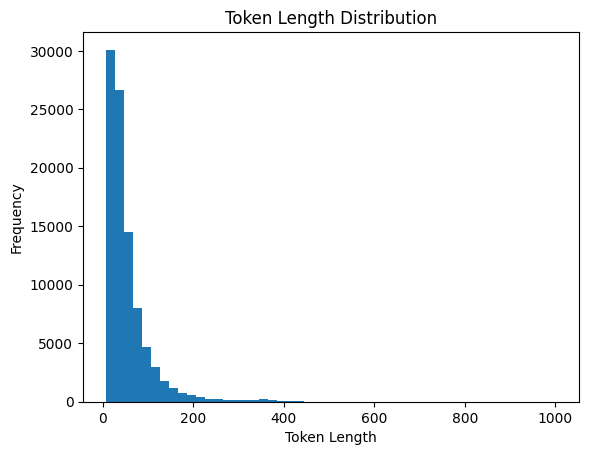

In [ ]:
# clean text
import re
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()

    # Lowercase
    text = text.lower()

    # Remove special characters / numbers (keep only letters)
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Optional: remove stopwords (for TF-IDF, not for embeddings)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Apply
df['clean_text'] = df['full_text'].apply(clean_text)
test_df['clean_text']  = test_df['QA Text'].apply(clean_text)
print(df['clean_text'].head())

# for skip gram
df['tokens'] = df['clean_text'].apply(word_tokenize)
all_words = [word for tokens in df['tokens'] for word in tokens]
print("Vocabulary size:", len(set(all_words)))

df['token_length'] = df['tokens'].apply(len)
plt.hist(df['token_length'], bins=50)
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

In [ ]:
# tfidf 1 (log reg)
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

X_train_text = df['clean_text']
y_train = df['Class']

X_test_text = test_df['clean_text']
y_test = test_df['Class']


tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2,
    max_features=50000,
    sublinear_tf=True,
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

# ===============================
# tuning
# ===============================

param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best hyperparameters:", grid_lr.best_params_)
print("Best CV Macro F1:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
best_lr.fit(X_train, y_train)

y_pred = best_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

results.append(evaluate_model("Logistic Regression + TF-IDF", accuracy, f1_macro, cm, report))

print("Accuracy:", accuracy)
print("F1-score (macro):", f1_macro)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

e:\University\440\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "e:\University\440\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\University\440\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\University\440\venv\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1208, in fit
    raise ValueError(


Best hyperparameters: {'C': 1, 'solver': 'lbfgs'}
Best CV Macro F1: 0.6836116700826093
Accuracy: 0.6704111735195587
F1-score (macro): 0.668081467344737

Confusion Matrix:
 [[2774  361  506  422  327  246  414  360  458  132]
 [ 264 4915  183  224   64   32   40  148   78   52]
 [ 347  190 2853  328  143  218  381  907  501  132]
 [ 198  215  216 3949  300  144  151  180  428  219]
 [ 188   76  121  370 4263  256  104   91  458   72]
 [ 119   37  164  131  337 4496   76  332  219   89]
 [ 372   58  288  142   83   73 4392  141  379   72]
 [ 118   96  532  129   31  324   99 4416  170   85]
 [ 228   64  457  425  568  233  416  212 3305   92]
 [ 121   67  137  273   72  130   87  137  115 4861]]

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.59      0.46      0.52      6000
  Computers & Internet       0.81      0.82      0.81      6000
 Education & Reference       0.52      0.48      0.50      6000
 Entertainment 

In [ ]:
# tfidf 2
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder


import keras_tuner as kt

def build_model(hp):
    model = Sequential([
        Dense(
            hp.Choice('units1', [256, 512]),
            activation='relu',
            input_shape=(X_train.shape[1],)
        ),
        Dropout(hp.Choice('dropout1', [0.4, 0.5])),

        Dense(
            hp.Choice('units2', [128, 256]),
            activation='relu'
        ),
        Dropout(hp.Choice('dropout2', [0.3, 0.4])),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('lr', [1e-3, 5e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


label_encoder = LabelEncoder()

X_train_text = df['clean_text']
y_train = label_encoder.fit_transform(df['Class'].values)

X_test_text = test_df['clean_text']
y_test = label_encoder.transform(test_df['Class'].values)

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Convert sparse matrices to dense arrays for DNN
X_train = X_train_tfidf.astype('float32').toarray()
X_test  = X_test_tfidf.astype('float32').toarray()


best_model = None
best_val_acc = 0
best_config = None

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,
    directory='tfidf_nn_tuning',
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

tuner.search(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,          # MAX epochs
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
for k in best_hp.values:
    print(f"{k}: {best_hp.get(k)}")

# ===============================
# 8. Evaluate on EXTERNAL Test Set
# ===============================

# Keras evaluation
loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

# Predictions
y_prob = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)


report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
# sklearn metrics
print("\nClassification Report:\n", report)

print("Confusion Matrix:\n", cm)

print("Accuracy (sklearn):", accuracy)
print("Macro F1:", f1)

results.append(evaluate_model("DNN + TF-IDF", accuracy, f1, cm, report))


e:\University\440\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Reloading Tuner from tfidf_nn_tuning\untitled_project\tuner0.json



e:\University\440\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters:
units1: 256
dropout1: 0.4
units2: 128
dropout2: 0.4
lr: 0.0005
Test Loss: 1.1343 | Test Accuracy: 0.6365

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.61      0.41      0.49      6000
  Computers & Internet       0.75      0.81      0.78      6000
 Education & Reference       0.53      0.40      0.46      6000
 Entertainment & Music       0.55      0.59      0.57      6000
Family & Relationships       0.62      0.74      0.68      5999
                Health       0.70      0.72      0.71      6000
 Politics & Government       0.65      0.73      0.69      6000
 Science & Mathematics       0.63      0.68      0.66      6000
     Society & Culture       0.52      0.53      0.53      6000
                Sports       0.75      0.75      0.75      6000

              accuracy                           0.64     59999
             macro avg       0.63      0.64      0.63     59999
          weig

In [ ]:
# re-formatting
df['tokens'] = df['clean_text'].apply(word_tokenize)
test_df['tokens'] = test_df['clean_text'].apply(word_tokenize)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

from gensim.models import Word2Vec

# tokens_list is a list of token lists (one per document)
tokens_list = df['tokens'].tolist()

skipgram_model = Word2Vec(
    sentences=tokens_list,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

import numpy as np

def document_vector(tokens, model):
    """Average word vectors for a document"""
    vecs = []
    for word in tokens:
        if word in model.wv:
            vecs.append(model.wv[word])
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    else:
        return np.zeros(model.vector_size)

# Apply to train/test
X_train = np.array([document_vector(tokens, skipgram_model) for tokens in df['tokens']])
X_test  = np.array([document_vector(tokens, skipgram_model) for tokens in test_df['tokens']])

y_train = label_encoder.fit_transform(df['Class'])
y_test  = label_encoder.transform(test_df['Class'])



In [ ]:
# Deep Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(hp):
    model = Sequential([
        Dense(
            hp.Choice('units1', [128, 256]),
            activation='relu',
            input_shape=(skipgram_model.vector_size,)
        ),
        Dropout(hp.Choice('dropout1', [0.4, 0.5])),

        Dense(
            hp.Choice('units2', [64, 128]),
            activation='relu'
        ),
        Dropout(hp.Choice('dropout2', [0.3, 0.4])),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('lr', [1e-3, 5e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


num_classes = len(label_encoder.classes_)

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,
    directory='sg_nn_tuning',
    project_name='skipgram_dnn'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

tuner.search(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,      # MAX epochs
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k in best_hp.values:
    print(f"{k}: {best_hp.get(k)}")

y_pred = np.argmax(best_model.predict(X_test), axis=1)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", report)

print("Confusion Matrix:\n", cm)

print("Accuracy (sklearn):", accuracy)
print("Macro F1:", f1)

results.append(evaluate_model("DNN + SG", accuracy, f1, cm, report))






Reloading Tuner from sg_nn_tuning\skipgram_dnn\tuner0.json
Best hyperparameters:
units1: 256
dropout1: 0.5
units2: 128
dropout2: 0.4
lr: 0.0005
   1/1875 ━━━━━━━━━━━━━━━━━━━━ 1:35 51ms/step

e:\University\440\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.70      0.35      0.47      6000
  Computers & Internet       0.83      0.79      0.81      6000
 Education & Reference       0.53      0.39      0.45      6000
 Entertainment & Music       0.60      0.63      0.61      6000
Family & Relationships       0.68      0.68      0.68      5999
                Health       0.66      0.80      0.72      6000
 Politics & Government       0.54      0.82      0.65      6000
 Science & Mathematics       0.63      0.75      0.68      6000
     Society & Culture       0.62      0.47      0.53      6000
                Sports       0.75      0.81      0.78      6000

              accuracy                           0.65     59999
             macro avg       0.65      0.65      0.64     59999
          weighted avg       0.65      0.65      0.64     59999

Confusion Matrix:
 [[2104  300 

In [ ]:
# SimpleRNN
import numpy as np

from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

X_train_text = df["clean_text"].astype(str)
X_test_text  = test_df["clean_text"].astype(str)

y_train_text = df["Class"]
y_test_text  = test_df["Class"]

le = LabelEncoder()
y_train = le.fit_transform(y_train_text)
y_test  = le.transform(y_test_text)

num_classes = len(le.classes_)

train_tokens = [text.split() for text in X_train_text]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=10
)

VOCAB_SIZE = 20000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, 100))

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

def build_model(hp):
    model = Sequential()

    model.add(
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=100,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        )
    )

    model.add(
        SimpleRNN(
            units=hp.Int("rnn_units", min_value=32, max_value=128, step=32),
            activation="tanh"
        )
    )

    model.add(
        Dropout(
            hp.Float("dropout", min_value=0.2, max_value=0.6, step=0.1)
        )
    )

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("lr", [1e-3, 5e-4, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

with tf.device('/GPU:0'):
    tuner = kt.RandomSearch(
        build_model,
        objective="val_accuracy",
        max_trials=10,           # increase to 20 if time allows
        executions_per_trial=1,
        directory="rnn_tuning",
        project_name="simple_rnn_w2v"
    )

    tuner.search(
        X_train_pad,
        y_train,
        epochs=10,
        validation_split=0.1,
        batch_size=64,
        verbose=1
    )

    best_model = tuner.get_best_models(num_models=1)[0]
    best_hp = tuner.get_best_hyperparameters(1)[0]

    print("Best hyperparameters:")
    for k in best_hp.values:
        print(f"{k}: {best_hp.get(k)}")

    loss, acc = best_model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f}")

    y_prob = best_model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print("\nClassification Report:\n", report)

    print("Confusion Matrix:\n", cm)

    print("Accuracy (sklearn):", accuracy)
    print("Macro F1:", f1)

    results.append(evaluate_model("SimpleRNN + SG", accuracy, f1, cm, report))


Reloading Tuner from rnn_tuning\simple_rnn_w2v\tuner0.json


e:\University\440\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters:
rnn_units: 96
dropout: 0.2
lr: 0.0001
Test Loss: 1.2964
Test Accuracy: 0.6093

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.64      0.34      0.44      6000
  Computers & Internet       0.84      0.78      0.80      6000
 Education & Reference       0.39      0.41      0.40      6000
 Entertainment & Music       0.42      0.70      0.53      6000
Family & Relationships       0.69      0.60      0.64      5999
                Health       0.80      0.66      0.72      6000
 Politics & Government       0.70      0.61      0.65      6000
 Science & Mathematics       0.61      0.72      0.66      6000
     Society & Culture       0.48      0.46      0.47      6000
                Sports       0.71      0.82      0.76      6000

              accuracy                           0.61     59999
             macro avg       0.63      0.61      0.61     59999
          weighted avg       0.63      0.

In [ ]:
# GRU

from tensorflow.keras.layers import GRU
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

def build_gru_model(hp):
    model = Sequential()

    model.add(
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=100,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        )
    )

    model.add(
        GRU(
            units=hp.Int("gru_units", min_value=32, max_value=128, step=32),
            return_sequences=False
        )
    )

    model.add(
        Dropout(
            hp.Float("dropout", min_value=0.2, max_value=0.6, step=0.1)
        )
    )

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("lr", [1e-3, 5e-4, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


with tf.device('/GPU:0'):

    tuner_gru = kt.RandomSearch(
        build_gru_model,
        objective="val_accuracy",
        max_trials=10,        # increase if time allows
        executions_per_trial=1,
        directory="rnn_tuning",
        project_name="gru_w2v"
    )

    tuner_gru.search(
        X_train_pad,
        y_train,
        epochs=15,
        validation_split=0.1,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1
    )

    best_gru_model = tuner_gru.get_best_models(num_models=1)[0]

    best_gru_model.summary()

    best_hp = tuner_gru.get_best_hyperparameters(1)[0]

    print("Best GRU Hyperparameters:")
    print("GRU units:", best_hp.get("gru_units"))
    print("Dropout:", best_hp.get("dropout"))
    print("Learning rate:", best_hp.get("lr"))



    # GRU evaluation
    loss_gru, acc_gru = best_gru_model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"GRU Test Loss: {loss_gru:.4f}")
    print(f"GRU Test Accuracy (Keras): {acc_gru:.4f}")

    y_prob_gru = best_gru_model.predict(X_test_pad, verbose=0)
    y_pred_gru = np.argmax(y_prob_gru, axis=1)

    report = classification_report(y_test, y_pred_gru, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred_gru)
    accuracy = accuracy_score(y_test, y_pred_gru)
    f1 = f1_score(y_test, y_pred_gru, average='macro')

    print("\nClassification Report:\n", report)

    print("Confusion Matrix:\n", cm)

    print("Accuracy (sklearn):", accuracy)
    print("Macro F1:", f1)

    results.append(evaluate_model("GRU + SG", accuracy, f1, cm, report))



Reloading Tuner from rnn_tuning\gru_w2v\tuner0.json


e:\University\440\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,089,610 (7.97 MB)

 Trainable params: 2,089,610 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

Best GRU Hyperparameters:
GRU units: 128
Dropout: 0.30000000000000004
Learning rate: 0.001
GRU Test Loss: 1.0130
GRU Test Accuracy (Keras): 0.6732

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.59      0.46      0.52      6000
  Computers & Internet       0.78      0.85      0.82      6000
 Education & Reference       0.58      0.42      0.49      6000
 Entertainment & Music       0.52      0.73      0.61      6000
Family & Relationships       0.73      0.67      0.69      5999
                Health       0.75      0.76      0.75      6000
 Politics & Government       0.73      0.73      0.73      6000
 Science & Mathematics       0.67      0.74      0.71      6000
     Society & Culture       0.55      0.55      0.55      6000
                Sports       0.85      0.83      0.84      6000

              accuracy                           0.67     59999
             macro avg       0.67      0.67      0.67     

In [ ]:
# LSTM

from tensorflow.keras.layers import LSTM

def build_lstm_model(hp):
    model = Sequential()

    model.add(
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=100,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        )
    )

    model.add(
        LSTM(
            units=hp.Int("lstm_units", min_value=32, max_value=128, step=32),
            return_sequences=False
        )
    )

    model.add(
        Dropout(
            hp.Float("dropout", min_value=0.2, max_value=0.6, step=0.1)
        )
    )

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("lr", [1e-3, 5e-4, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

with tf.device('/GPU:0'):

    tuner_lstm = kt.RandomSearch(
        build_lstm_model,
        objective="val_accuracy",
        max_trials=10,        # increase if time allows
        executions_per_trial=1,
        directory="rnn_tuning",
        project_name="lstm_w2v"
    )

    tuner_lstm.search(
        X_train_pad,
        y_train,
        epochs=15,
        validation_split=0.1,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1
    )

    best_lstm_model = tuner_lstm.get_best_models(num_models=1)[0]

    best_lstm_model.summary()

    best_hp = tuner_lstm.get_best_hyperparameters(1)[0]

    print("Best LSTM Hyperparameters:")
    print("LSTM units:", best_hp.get("lstm_units"))
    print("Dropout:", best_hp.get("dropout"))
    print("Learning rate:", best_hp.get("lr"))



    # LSTM evaluation
    loss_lstm, acc_lstm = best_lstm_model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"LSTM Test Loss: {loss_lstm:.4f}")
    print(f"LSTM Test Accuracy (Keras): {acc_lstm:.4f}")

    y_prob_lstm = best_lstm_model.predict(X_test_pad, verbose=0)
    y_pred_lstm = np.argmax(y_prob_lstm, axis=1)

    report = classification_report(y_test, y_pred_lstm, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred_lstm)
    accuracy = accuracy_score(y_test, y_pred_lstm)
    f1 = f1_score(y_test, y_pred_lstm, average='macro')

    print("\nClassification Report:\n", report)

    print("Confusion Matrix:\n", cm)

    print("Accuracy (sklearn):", accuracy)
    print("Macro F1:", f1)

    results.append(evaluate_model("LSTM + SG", accuracy, f1, cm, report))



Reloading Tuner from rnn_tuning\lstm_w2v\tuner0.json


e:\University\440\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 96)             │        75,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076,618 (7.92 MB)

 Trainable params: 2,076,618 (7.92 MB)

 Non-trainable params: 0 (0.00 B)

Best LSTM Hyperparameters:
LSTM units: 96
Dropout: 0.5
Learning rate: 0.001
LSTM Test Loss: 1.0574
LSTM Test Accuracy (Keras): 0.6678

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.50      0.50      0.50      6000
  Computers & Internet       0.83      0.82      0.83      6000
 Education & Reference       0.54      0.44      0.48      6000
 Entertainment & Music       0.61      0.65      0.63      6000
Family & Relationships       0.66      0.72      0.69      5999
                Health       0.72      0.76      0.74      6000
 Politics & Government       0.71      0.74      0.73      6000
 Science & Mathematics       0.71      0.67      0.69      6000
     Society & Culture       0.54      0.55      0.55      6000
                Sports       0.82      0.83      0.83      6000

              accuracy                           0.67     59999
             macro avg       0.67      0.67      0.67     59999
       

In [ ]:
# Bidirectional SimpleRNN
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

def build_birnn_model(hp):
    model = Sequential()
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=100,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ))

    # Tune RNN units
    model.add(Bidirectional(SimpleRNN(
        hp.Int('birnn_units', min_value=32, max_value=128, step=32))))

    # Tune dropout
    model.add(Dropout(
        hp.Float('dropout', min_value=0.2, max_value=0.6, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    # Tune learning rate
    optimizer = Adam(
        learning_rate=hp.Choice('lr', values=[1e-2, 1e-3, 1e-4]), clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



with tf.device('/GPU:0'):
    tuner_birnn = kt.RandomSearch(
        build_birnn_model,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory='rnn_tuning',
        project_name='birnn_w2v'
    )

    tuner_birnn.search(X_train_pad, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    best_birnn_model = tuner_birnn.get_best_models(num_models=1)[0]
    best_birnn_model.summary()

    best_hp = tuner_birnn.get_best_hyperparameters(1)[0]

    print("Best Bi SimpleRNN Hyperparameters:")
    print("Bi SimpleRNN units:", best_hp.get("birnn_units"))
    print("Dropout:", best_hp.get("dropout"))
    print("Learning rate:", best_hp.get("lr"))

    loss_birnn, acc_birnn = best_birnn_model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"BiRNN Test Loss: {loss_birnn:.4f}")
    print(f"BiRNN Test Accuracy (Keras): {acc_birnn:.4f}")

    y_prob_birnn = best_birnn_model.predict(X_test_pad, verbose=0)
    y_pred_birnn = np.argmax(y_prob_birnn, axis=1)

    report = classification_report(y_test, y_pred_birnn, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred_birnn)
    accuracy = accuracy_score(y_test, y_pred_birnn)
    f1 = f1_score(y_test, y_pred_birnn, average='macro')

    print("\nClassification Report:\n", report)

    print("Confusion Matrix:\n", cm)

    print("Accuracy (sklearn):", accuracy)
    print("Macro F1:", f1)

    results.append(evaluate_model("Bi SimpleRNN + SG", accuracy, f1, cm, report))



Reloading Tuner from rnn_tuning\birnn_w2v\tuner0.json


e:\University\440\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 192)            │        37,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,039,754 (7.78 MB)

 Trainable params: 2,039,754 (7.78 MB)

 Non-trainable params: 0 (0.00 B)

Best Bi SimpleRNN Hyperparameters:
Bi SimpleRNN units: 96
Dropout: 0.2
Learning rate: 0.0001
BiRNN Test Loss: 1.1340
BiRNN Test Accuracy (Keras): 0.6454

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.54      0.45      0.49      6000
  Computers & Internet       0.86      0.76      0.81      6000
 Education & Reference       0.50      0.42      0.46      6000
 Entertainment & Music       0.59      0.65      0.62      6000
Family & Relationships       0.57      0.77      0.65      5999
                Health       0.62      0.77      0.69      6000
 Politics & Government       0.72      0.70      0.71      6000
 Science & Mathematics       0.72      0.65      0.68      6000
     Society & Culture       0.53      0.52      0.52      6000
                Sports       0.87      0.77      0.82      6000

              accuracy                           0.65     59999
             macro avg       0.65      0.65      0.6

In [ ]:
# Bidirectional GRU

from tensorflow.keras.layers import GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import tensorflow as tf

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

def build_bigru_model(hp):
    model = Sequential()
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=100,
        weights=[np.asarray(embedding_matrix, dtype=np.float32)],
        input_length=MAX_LEN,
        trainable=True
    ))

    # Tune RNN units
    model.add(Bidirectional(GRU(
        hp.Int('bigru_units', min_value=32, max_value=128, step=32))))

    # Tune dropout
    model.add(Dropout(
        hp.Float('dropout', min_value=0.2, max_value=0.6, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    # Tune learning rate
    optimizer = Adam(
        learning_rate=hp.Choice('lr', values=[1e-2, 1e-3, 1e-4]), clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



with tf.device('/GPU:0'):
    tuner_bigru = kt.RandomSearch(
        build_bigru_model,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory='rnn_tuning',
        project_name='bigru_w2v'
    )

    tuner_bigru.search(X_train_pad, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    best_bigru_model = tuner_bigru.get_best_models(num_models=1)[0]
    best_bigru_model.summary()

    best_hp = tuner_bigru.get_best_hyperparameters(1)[0]

    print("Best Bi GRU Hyperparameters:")
    print("Bi GRU units:", best_hp.get("bigru_units"))
    print("Dropout:", best_hp.get("dropout"))
    print("Learning rate:", best_hp.get("lr"))

    loss_bigru, acc_bigru = best_bigru_model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"BiGRU Test Loss: {loss_bigru:.4f}")
    print(f"BiGRU Test Accuracy: {acc_bigru:.4f}")

    y_prob_bigru = best_bigru_model.predict(X_test_pad, verbose=0)
    y_pred_bigru = np.argmax(y_prob_bigru, axis=1)

    report = classification_report(y_test, y_pred_bigru, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred_bigru)
    accuracy = accuracy_score(y_test, y_pred_bigru)
    f1 = f1_score(y_test, y_pred_bigru, average='macro')

    print("\nClassification Report:\n", report)

    print("Confusion Matrix:\n", cm)

    print("Accuracy (sklearn):", accuracy)
    print("Macro F1:", f1)

    results.append(evaluate_model("Bi GRU + SG", accuracy, f1, cm, report))



Reloading Tuner from rnn_tuning\bigru_w2v\tuner0.json


e:\University\440\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,179,210 (8.31 MB)

 Trainable params: 2,179,210 (8.31 MB)

 Non-trainable params: 0 (0.00 B)

Best Bi GRU Hyperparameters:
Bi GRU units: 128
Dropout: 0.4
Learning rate: 0.001
BiGRU Test Loss: 1.0115
BiGRU Test Accuracy: 0.6752

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.63      0.45      0.52      6000
  Computers & Internet       0.80      0.85      0.82      6000
 Education & Reference       0.53      0.46      0.49      6000
 Entertainment & Music       0.56      0.69      0.62      6000
Family & Relationships       0.69      0.70      0.70      5999
                Health       0.74      0.77      0.75      6000
 Politics & Government       0.71      0.73      0.72      6000
 Science & Mathematics       0.69      0.72      0.70      6000
     Society & Culture       0.55      0.56      0.55      6000
                Sports       0.85      0.83      0.84      6000

              accuracy                           0.68     59999
             macro avg       0.67      0.68      0.67     59999
        

In [ ]:
# Bidirectional LSTM
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import tensorflow as tf

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

def build_bilstm_model(hp):
    model = Sequential()
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=100,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ))

    # Tune RNN units
    model.add(Bidirectional(LSTM(
        hp.Int('bilstm_units', min_value=32, max_value=128, step=32))))

    # Tune dropout
    model.add(Dropout(
        hp.Float('dropout', min_value=0.2, max_value=0.6, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    # Tune learning rate
    optimizer = Adam(
        learning_rate=hp.Choice('lr', values=[1e-2, 1e-3, 1e-4]), clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


with tf.device('/GPU:0'):
    tuner_bilstm = kt.RandomSearch(
        build_bilstm_model,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory='rnn_tuning',
        project_name='bilstm_w2v'
    )

    tuner_bilstm.search(X_train_pad, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    best_bilstm_model = tuner_bilstm.get_best_models(num_models=1)[0]
    best_bilstm_model.summary()

    best_hp = tuner_bilstm.get_best_hyperparameters(1)[0]

    print("Best Bi LSTM Hyperparameters:")
    print("Bi LSTM units:", best_hp.get("bilstm_units"))
    print("Dropout:", best_hp.get("dropout"))
    print("Learning rate:", best_hp.get("lr"))

    loss_bilstm, acc_bilstm = best_bilstm_model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"BiLSTM Test Loss: {loss_bilstm:.4f}")
    print(f"BiLSTM Test Accuracy: {acc_bilstm:.4f}")

    y_prob_bilstm = best_bilstm_model.predict(X_test_pad, verbose=0)
    y_pred_bilstm = np.argmax(y_prob_bilstm, axis=1)

    report = classification_report(y_test, y_pred_bilstm, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred_bilstm)
    accuracy = accuracy_score(y_test, y_pred_bilstm)
    f1 = f1_score(y_test, y_pred_bilstm, average='macro')

    print("\nClassification Report:\n", report)

    print("Confusion Matrix:\n", cm)

    print("Accuracy (sklearn):", accuracy)
    print("Macro F1:", f1)

    results.append(evaluate_model("Bi GRU + SG", accuracy, f1, cm, report))



Reloading Tuner from rnn_tuning\bilstm_w2v\tuner0.json


e:\University\440\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
e:\University\440\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 192)            │       151,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,153,226 (8.21 MB)

 Trainable params: 2,153,226 (8.21 MB)

 Non-trainable params: 0 (0.00 B)

Best Bi LSTM Hyperparameters:
Bi LSTM units: 96
Dropout: 0.5
Learning rate: 0.001
BiLSTM Test Loss: 1.0519
BiLSTM Test Accuracy: 0.6612

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.72      0.35      0.47      6000
  Computers & Internet       0.65      0.88      0.75      6000
 Education & Reference       0.66      0.33      0.44      6000
 Entertainment & Music       0.52      0.73      0.61      6000
Family & Relationships       0.71      0.67      0.69      5999
                Health       0.73      0.77      0.75      6000
 Politics & Government       0.71      0.74      0.73      6000
 Science & Mathematics       0.70      0.71      0.70      6000
     Society & Culture       0.53      0.58      0.55      6000
                Sports       0.75      0.86      0.80      6000

              accuracy                           0.66     59999
             macro avg       0.67      0.66      0.65     59999
     

In [ ]:
summary_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Macro F1": r["Macro F1"]
    }
    for r in results
]).sort_values("Macro F1", ascending=False)

summary_df

,Model,Accuracy,Macro F1
7,Bi GRU + SG,0.675195,0.672141
4,GRU + SG,0.673161,0.669585
0,Logistic Regression + TF-IDF,0.670411,0.668081
5,LSTM + SG,0.667778,0.665912
8,Bi GRU + SG,0.661178,0.649198
6,Bi SimpleRNN + SG,0.645361,0.644038
2,DNN + SG,0.648777,0.638921
1,DNN + TF-IDF,0.636494,0.630799
3,SimpleRNN + SG,0.609327,0.608623


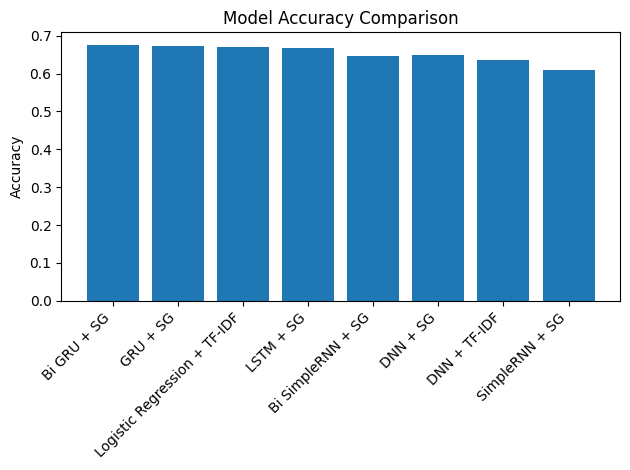

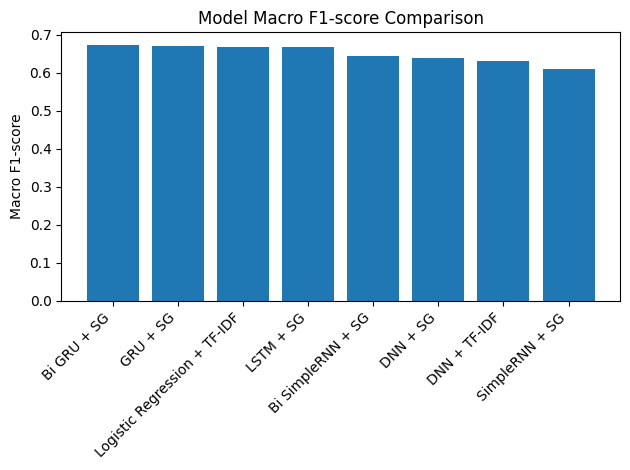

<Figure size 640x480 with 0 Axes>

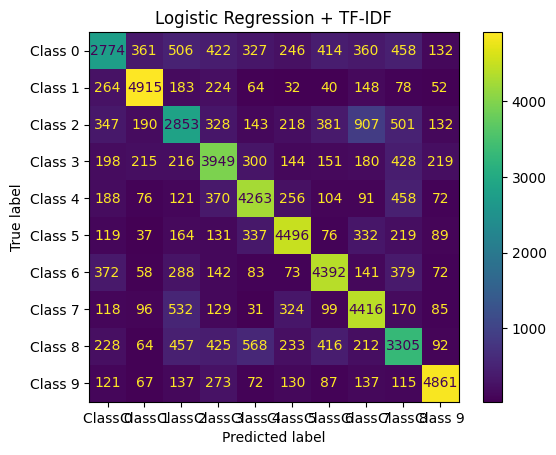

<Figure size 640x480 with 0 Axes>

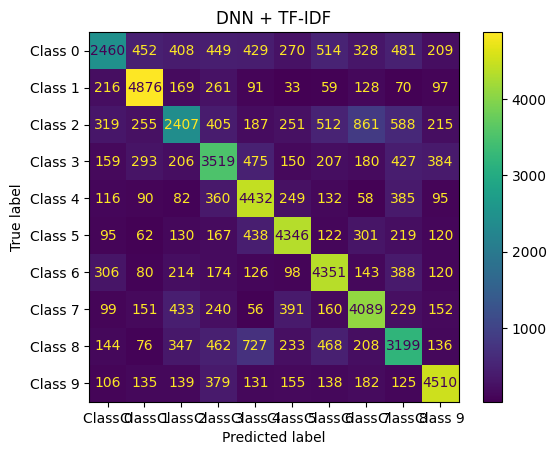

<Figure size 640x480 with 0 Axes>

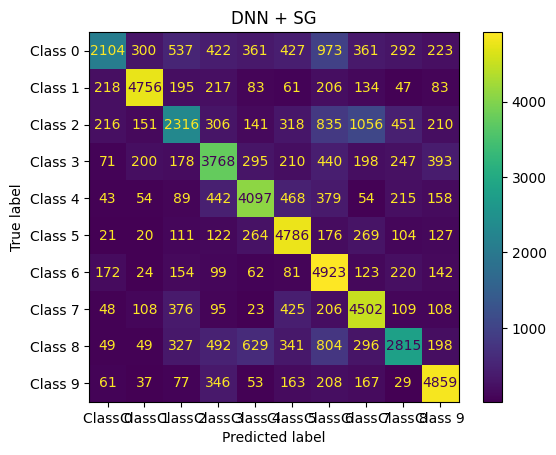

<Figure size 640x480 with 0 Axes>

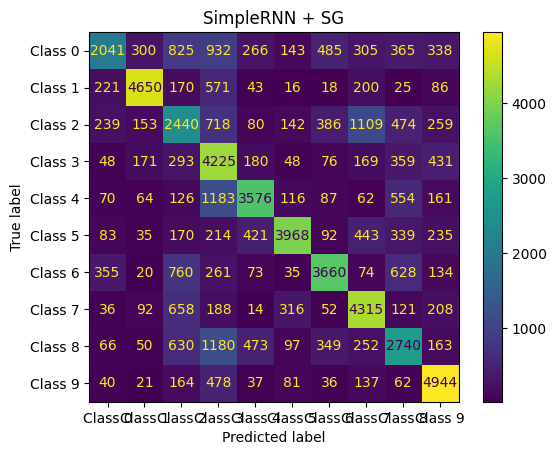

<Figure size 640x480 with 0 Axes>

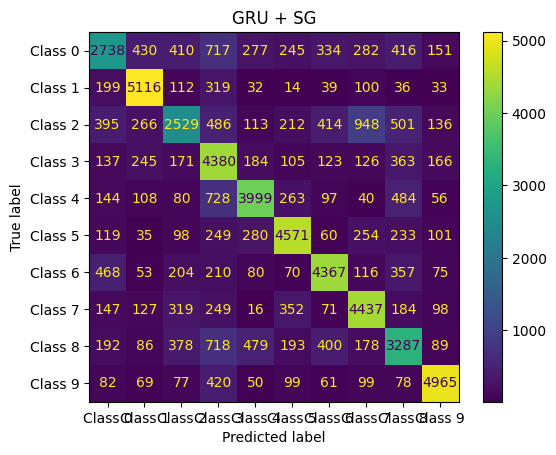

<Figure size 640x480 with 0 Axes>

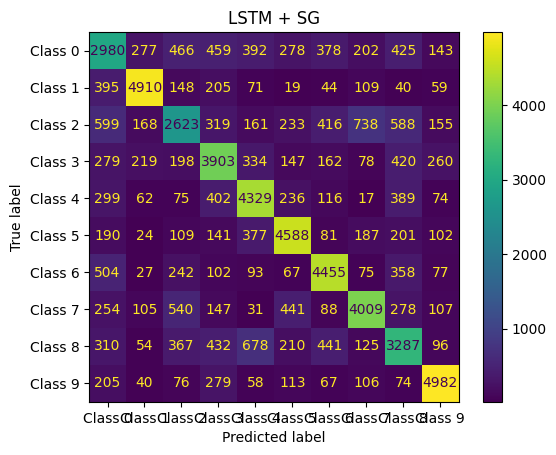

<Figure size 640x480 with 0 Axes>

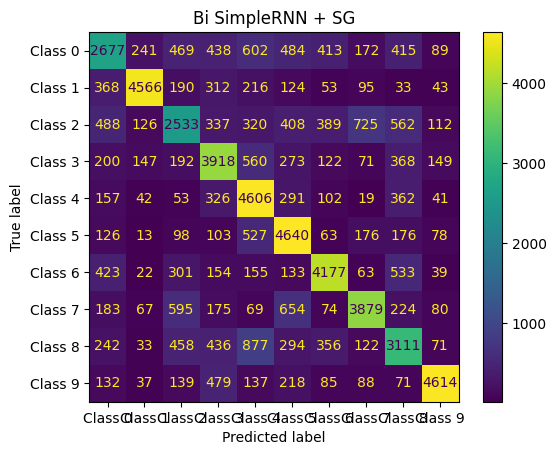

<Figure size 640x480 with 0 Axes>

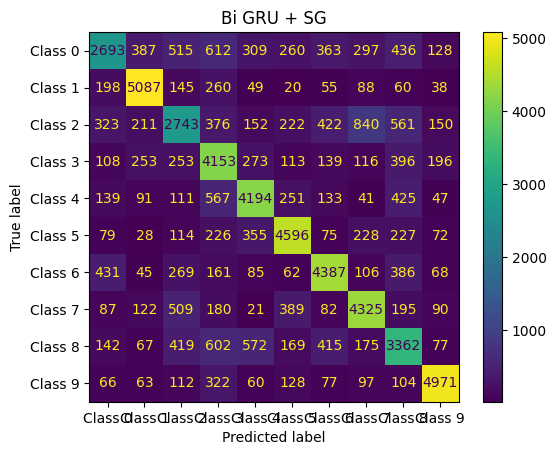

<Figure size 640x480 with 0 Axes>

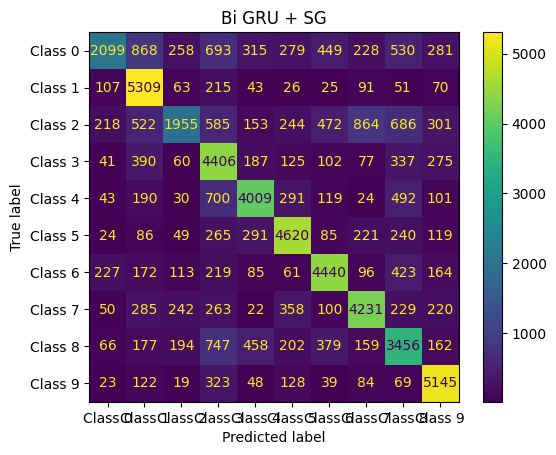

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure()
plt.bar(summary_df["Model"], summary_df["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(summary_df["Model"], summary_df["Macro F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1-score")
plt.title("Model Macro F1-score Comparison")
plt.tight_layout()
plt.show()


class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4", "Class 5", "Class 6", "Class 7", "Class 8", "Class 9"]

for r in results:
    plt.figure()
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r["Confusion Matrix"],
        display_labels=class_names
    )
    disp.plot()
    plt.title(r["Model"])
    plt.show()




In [ ]:
# Identify best ML model
ml_models = summary_df[
    summary_df["Model"].str.contains("TF-IDF")
]

nn_models = summary_df[
    summary_df["Model"].str.contains("SG")
]
best_ml = ml_models.sort_values("Macro F1", ascending=False).iloc[0]
best_nn = nn_models.sort_values("Macro F1", ascending=False).iloc[0]

comparison_df = pd.DataFrame([best_ml, best_nn])
comparison_df


,Model,Accuracy,Macro F1
0,Logistic Regression + TF-IDF,0.670411,0.668081
7,Bi GRU + SG,0.675195,0.672141
